# Subtiles 2
---
<img src='https://www.janestreet.com/puzzles/subtiles-2.jpg' width=700 align='center'/>


Place positive integers in some of the cells above, so that the grid contains one 1, two 2’s, three 3’s, and so on, up to $N$ $N$’s. (For some $N$.)

For any integer $K$ in the grid, the cells labeled $K$ must form an orthogonally connected region (a “K-omino”). Furthermore, for each $K$ > 1 the $K$-omino must “contain” the shape formed by the ($K−1$)’s. (Rotations and reflections are allowed.)

Some of the cells have been labeled, but unlike our previous Subtiles, we have used variables to obscure those values. (As in the example, at the bottom.)

After completing the grid, compute, in each row, the sum of the labeled cells. The answer to this puzzle is the product of the maximum and minimum row sums.

## Solving the example
---
To solve the example it's I broke it down into three steps:
1. Find the maximum length $K$-omino you can fit in the grid
2. Solve the constraint satisfaction problem for the cells (leads to middle example grid)*
3. Find how the K-omino's are arranged in the grid

> Note the example CSP has two solutions, (x = 2, y = 6) and (x = 2, y = 4), the latter can be discarded because it leads to an unsolvable grid.

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sympy as sp
from z3 import *

In [2]:
#Function that will be used multiple times to visualise the grids
def gridshow(grid: np.array) -> None:
    mask = grid == 0
    palette = sns.color_palette("hls", 17)
    cmap = sns.color_palette(palette, as_cmap=True)
    plt.figure(figsize=(8, 8))
    heatmap = sns.heatmap(grid, mask = mask, annot=True, cmap=cmap, cbar=False, xticklabels = False, yticklabels = False, linewidths=1, linecolor="black")
    plt.show()

In [3]:
k, n = sp.symbols('k n')
S = sp.Sum(k, (k, 1, n)).doit()

z = 0
while S.subs(n,z) < 5*5:
    z += 1

print(f"The maximum length of a K-omino in example grid is {z - 1}")

The maximum length of a K-omino in example grid is 6


In [4]:
x = Int('x')
y = Int('y')
s = Solver()

s.add(y % x == 0)
s.add(7 > 3*x, 3*x > 0)
s.add(x != 0)
s.add(y != 0)
s.add(7 > 2*x + 1, 2*x + 1 > 0)
s.add(7 > x**2, x**2 > 0)
s.add(y > 0, y <= 7)
s.add(x > 0, x <= 7)
s.add(y > 0, y <= 6)
s.add(7 > y - x, y - x > 0)
s.add(7 > x**3 - y, x**3 - y > 0)

solutions = []

while s.check() == sat:
    m = s.model()
    
    x_val = m[x].as_long()
    y_val = m[y].as_long()
    
    solutions.append((x_val, y_val))
    print("Solution:", x_val, y_val)
    s.add(Or(x != x_val, y != y_val))

print(solutions)

Solution: 2 4
Solution: 2 6
[(2, 4), (2, 6)]


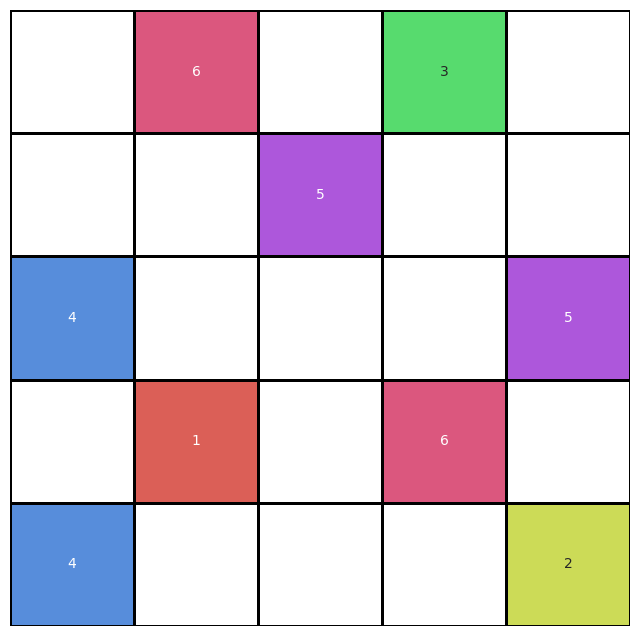

In [5]:
x, y = sp.symbols('x y')

grid = [
        [0, 3*x, 0, y/x, 0], 
        [0, 0, 2*x + 1, 0, 0],
        [x**2, 0, 0, 0, y - 1],
        [0, x - 1, 0, y, 0],
        [y - x, 0, 0, 0, x**3 - y]
       ]

for row in grid:
    for i in range(len(row)):
        if row[i] == 0:
            continue
        else:
            row[i] = int(row[i].subs([(x, 2), (y, 6)]))

grid = np.array(grid)
gridshow(grid)

Once you get to this point, I recommend:
- Screenshotting the grid
- Opening it up on paint
- Filling in the obvious ones (connect the 6 cells and the shapes are pretty much determined)

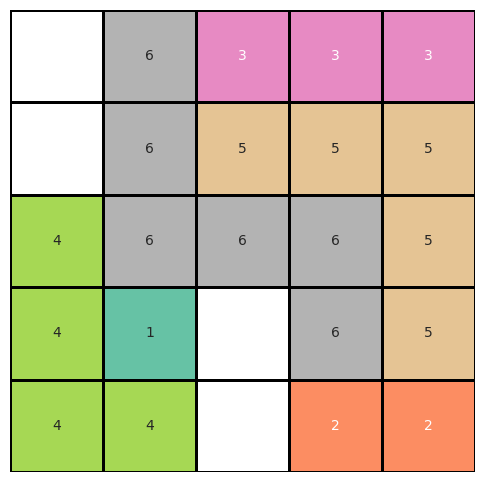

In [6]:
grid = [
        [0,6,3,3,3],
        [0,6,5,5,5],
        [4,6,6,6,5],
        [4,1,0,6,5],
        [4,4,0,2,2]
        ]            

grid = np.array(grid)
mask = grid == 0

plt.figure(figsize=(6, 6))
heatmap = sns.heatmap(grid, mask = mask, annot=True, cmap='Set2', cbar=False, xticklabels = False, yticklabels = False, linewidths=1, linecolor="black")
plt.show()

## Solving the puzzle grid
---

The process is very much the same.

In [7]:
while S.subs(n,z) < 13*13:
    z += 1

print(f"Max length K-omino is {z-1}")


a = Real('a')
b = Real('b')
c = Real('c')
k, k1, k2, k3, k4, k5, k6, k7, k8, k9, k10, k11, k12, k13, k14 = Ints('k k1 k2 k3 k4 k5 k6 k7 k8 k9 k10 k11 k12 k13 k14')

s = Solver()

bounded = [
        6*c - 4*b,
        8 - b,
        8*a - 2*b,
        4*a - 5*b,
        c + 2*a,
        2*c + c/a,
        11 - b,
        8*c - b/c,
        (b - 1)**2,
        (b + c)/(c - 1),
        (a + b)/(c - 3*a),
        (b - 3*a)/(a - c),
        b/(a-c),
        18/(a*c + 1),
        b/(a**2 - c**2),
        b/(9*a - 5*c),
        b/(a - 1),
        (c - b)/2*a,
        b/(a-c),
        (b + c)/(a - c),
        (c**2 - b)/a,
        (b - a)/(a - c),
        (b - 2*a)/(a - c),
        (c + 3)/a
        ]

for e in bounded:
    s.add(z > e, e > 0)
    
#Bigger than zero
btz = [
        30 + a,
        c - a,
        a + 2,
        c,
        a,
        43 - a*c
    ]

for e in btz:
    s.add(e > 0)

nz = [
        6*c + 1,
        b + c,
        c - 1,
        c,
        c - 3*a,
        a + b,
        b - 3*a,
        b,
        a - c,
        b + 9,
        a*c + 1,
        a**2 + c**2,
        a,
        9*a - 5*c,
        b + 2*c,
        a - 1,
        c - b,
        b + c,
        c**2 - b,
        a,
        b - 1,
        b - a,
        b - 2*a,
        a - c,
        c + 3
    ]

for e in nz:
    s.add(e != 0)


s.add((b + c)/(c - 1) == k)
s.add((a + b)/(c - 3*a) == k1)
s.add((b - 3*a)/(a - c) == k2)
s.add(b/(a-c) == k3)
s.add(18/(a*c + 1) == k4)
#s.add(b/(a**2 - c**2) == k5)
s.add(b/(9*a - 5*c) == k6)
s.add(b/(a - 1) == k7)
s.add((c - b)/(2*a) == k8)
s.add(b/(a-c) == k9)
s.add((b + c)/(a - c) == k10)
s.add((c**2 - b)/a == k11)
s.add((b - a)/(a - c) == k12)
s.add((b - 2*a)/(a - c) == k13)
s.add((c + 3)/a == k14)

if s.check() == sat:
    m = s.model()
    print(f"a is {m[a]}, b is {m[b]} and c is {m[c]}")

Max length K-omino is 17
a is 1/4, b is -3 and c is 1/2


>Note that Z3 sometimes solves the CSP to yield b = -3/2 but that leads to an unsolvable board.

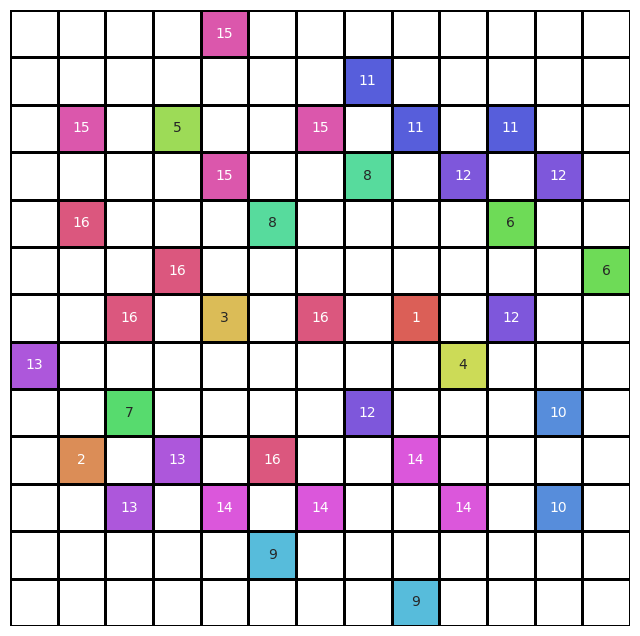

In [8]:
a, b, c, k, n = sp.symbols('a b c k n')

grid = [
         [0, 0, 0, 0, 6*c - 4*b, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 8 - b, 0, 0, 0, 0, 0],
         [0, (a**b - 4)/(6*c + 1), 0, (b + c)/(c - 1), 0, 0, b**2 - b/c, 0, sp.sqrt(30 + a)/c, 0, (a + b)/(c - 3*a), 0, 0],
         [0, 0, 0, 0, (b - 3*a)/(a - c), 0, 0, 8*a - 2*b, 0, b/(a - c), 0, (b + 9)/sp.sqrt(c - a), 0],
         [0, 18/(a*c + 1), 0, 0, 0, c**b, 0, 0, 0, 0, (3 + b**2)/sp.sqrt(3 + 2*c), 0, 0],
         [0, 0, 0, b/(a**2 - c**2), 0, 0, 0, 0, 0, 0, 0, 0, sp.sqrt(a + 2)/a],
         [0, 0, a**b - 12/a, 0, 2*c + c/a, 0, 4*a - 5*b, 0, c + 2*a, 0, b/(9*a - 5*c), 0, 0],
         [(b**3 + 2*c)/(b + 2*c), 0, 0, 0, 0, 0, 0, 0, 0, b/(a - 1), 0, 0, 0],
         [0, 0, (c - b)/(2*a), 0, 0, 0, 0, b/(a - c), 0, 0, 0, (b + c)/(a - c), 0],
         [0, sp.log(a,c), 0, (c**2 - b)/a, 0, (b - 1)**2, 0, 0, ((43 - a*c)**(1/3))/a, 0, 0, 0, 0],
         [0, 0, (b - a)/(a - c), 0, 11 - b, 0, (b - 2*a)/(a - c), 0, 0, (c + 3)/a, 0, 8*c - b/c, 0],
         [0, 0, 0, 0, 0, b**2, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, (2**b + 1)/(a*c), 0, 0, 0, 0]
]

for row in grid:
    for i in range(len(row)):
        if row[i] == 0:
            continue
        else:
            row[i] = float(row[i].subs([(a, 0.25), (b, -3), (c, 0.5)]))
            
grid = np.array(grid)
gridshow(grid)

Once again:
- Screenshot the grid
- Open it in paint
- Try to see which ones you can solve logically
---


The trick to solving this one by hand is to start with the 12 cells as they are the most distant away and there are only **two** ways to connect them, shown below.

Below is the **WRONG** 12-mino.

<img src='12-mino_WRONG.png' width=700 align='center'/>

Below is the **RIGHT** 12-mino.

<img src='12-mino_RIGHT.png' width=700 align='center'/>

It really helps to select a specific $K$-omino in paint, copy and paste them to the side of the grid and rotate them to see where you could fit them in the board for numbers $K + 1$ and $K - 1$.

That's how you solve 12, then 12 -> 11, 12 -> 13, 13 -> 14 etc. The more you fill in the more you can discard and the more hints you have at what other $K$-ominos look like.


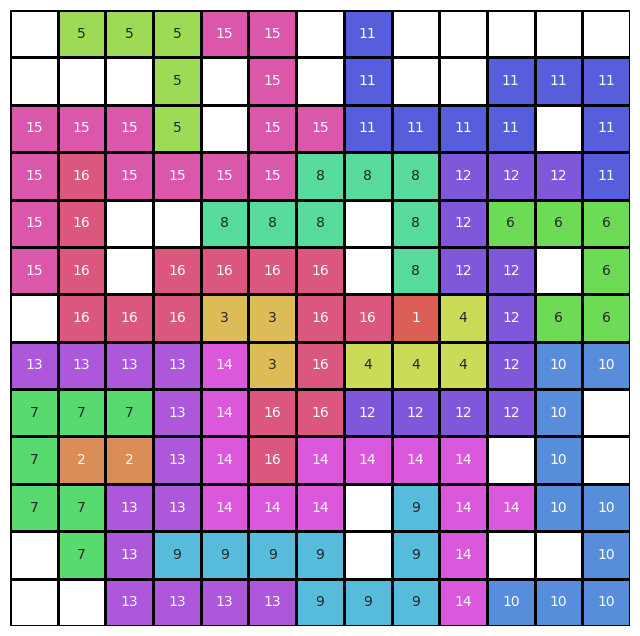

The max row sum is 162
The min row sum is 56
SOLUTION: The product of the two is 9072


In [9]:
grid = [
        [0, 5, 5, 5, 15, 15, 0, 11, 0, 0, 0, 0, 0],
        [0, 0, 0, 5, 0, 15, 0, 11, 0, 0, 11, 11, 11],
        [15, 15, 15, 5, 0, 15, 15, 11, 11, 11, 11, 0, 11],
        [15, 16, 15, 15, 15, 15, 8, 8, 8, 12, 12, 12, 11],
        [15, 16, 0, 0, 8, 8, 8, 0, 8, 12, 6, 6, 6],
        [15, 16, 0, 16, 16, 16, 16, 0, 8, 12, 12, 0, 6],
        [0, 16, 16, 16, 3, 3, 16, 16, 1, 4, 12, 6, 6],
        [13, 13, 13, 13, 14, 3, 16, 4, 4, 4, 12, 10, 10],
        [7, 7, 7, 13, 14, 16, 16, 12, 12, 12, 12, 10, 0],
        [7, 2, 2, 13, 14, 16, 14, 14, 14, 14, 0, 10, 0],
        [7, 7, 13, 13, 14, 14, 14, 0, 9, 14, 14, 10, 10],
        [0, 7, 13, 9, 9, 9, 9, 0, 9, 14, 0, 0, 10],
        [0, 0, 13, 13, 13, 13, 9, 9, 9, 14, 10, 10, 10]
]

grid = np.array(grid)
gridshow(grid)

row_max = -1
row_min = 10000000
for row in grid:
    temp = sum(row)
    if temp > row_max:
        row_max = temp

    if temp < row_min:
        row_min = temp

print(f"The max row sum is {row_max}")
print(f"The min row sum is {row_min}")
print(f"SOLUTION: The product of the two is {row_max * row_min}")